# Plots for Barcharts

#### Content
* [Single-node experiments](#single-node)
    * [Collect data](#collect-data)
    * [Heat maps](#heat-maps)  
    * [Barplots](#bar-plots)  



##### Packages and main formatting parameters

In [1]:
# executed in conda environment 'plotting' created with ./20_conda_envs/create_env.sh

# packages and overall options
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.lines as lines
import matplotlib.patches as patches
import matplotlib.lines as mlines
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import json
import sys
import math
import re
import itertools
import warnings
from pathlib import Path

bol_paper = True

if bol_paper:
    sns.set(style='white', font='serif', font_scale=1.5)
    # fontsize for annotation
    font_size = 13
    fig_width = 9
    fig_height = 4
    # Set Seaborn style without grid
    plt.rcParams['xtick.major.size'] = 4
    plt.rcParams['ytick.major.size'] = 4
    plt.rcParams['xtick.bottom'] = True
    plt.rcParams['ytick.left'] = True   
    # out path
    out_folder = ''
    legend_anchor=1.2
else:
    sns.set(style='white', font='sans serif', font_scale=1.3)
    # fontsize for annotation
    font_size = 14
    # figur width and height
    fig_width = 10
    fig_height = 4
    # Set Seaborn style without grid
    plt.rcParams['xtick.major.size'] = 6
    plt.rcParams['ytick.major.size'] = 6
    plt.rcParams['xtick.bottom'] = True
    plt.rcParams['ytick.left'] = True
    # out path
    out_folder = 'presentations'
    legend_anchor=1.2

# colors
# custom_palette = sns.color_palette('colorblind')
# we use the IBM color design which looks ok for all:https://forum.shotcut.org/t/palette-for-colour-blindness/32219
ibm_colors_hex = ['#648FFF', '#785EF0', '#DC267F', '#FE6100', '#FFB000']

# Function to lighten colors
def lighten_color(hex_color, factor=0.25):
    """Lightens the given color by blending it with white."""
    rgb = mcolors.hex2color(hex_color)  # Convert to RGB (0-1 range)
    light_rgb = [(1 - factor) * c + factor for c in rgb]  # Blend with white
    return mcolors.to_hex(light_rgb)

# Generate lightened versions of IBM colors
light_ibm_colors_hex = [lighten_color(color, factor=0.25) for color in ibm_colors_hex]

# Add three shades of grey
grey_shades = ['#D3D3D3', '#A9A9A9', '#696969']

# Combine into an extended color palette
extended_colors = ibm_colors_hex + grey_shades + light_ibm_colors_hex

custom_palette = sns.color_palette(extended_colors)

# annotation color on columns
annotate_color='black'

# Own color map
# # Absolute values: low -> high: yellow → orange → red
# heatmap_cmap = mcolors.LinearSegmentedColormap.from_list(
#     'ibm_yellow_red',
#     [ibm_colors_hex[4], ibm_colors_hex[3], ibm_colors_hex[2]]
# )

# # white-red:
# heatmap_cmap = mcolors.LinearSegmentedColormap.from_list(
#     'ibm_white_red',
#     ['#FFFFFF', ibm_colors_hex[2]]
# )

# blue-white:
heatmap_cmap = mcolors.LinearSegmentedColormap.from_list(
    'ibm_blue_white',
    [
        # '#FFFFFF'
         mcolors.to_hex(
            np.array(mcolors.to_rgb(grey_shades[0])) * 0.3
            + np.ones(3) * 0.7
        ),    
        mcolors.to_hex(
            np.array(mcolors.to_rgb(ibm_colors_hex[0])) * 0.6
            + np.ones(3) * 0.4
        ),            
    ]
)

# Relative change: better -> same -> worse: blue → white → red
heatmap_diverging_cmap = mcolors.LinearSegmentedColormap.from_list(
    'ibm_blue_red',
    [ibm_colors_hex[0], '#FFFFFF', ibm_colors_hex[2]]
)


##### Helper functions

In [2]:
def apply_filters(df, filter_cols):
    for col, vals in filter_cols:
        if vals is None:
            df = df[df[col].isna()]
        else:
            df = df[df[col].isin(vals)]
    return df

def format_with_decimals(value, tick_number):
    return f'{value:.1f}'

def format_thousands_separator(x, digits=1):
    try:
        num = float(x)
        if num.is_integer():
            return f"{num:,.0f}".replace(',', "'")
        else:
            return f"{num:,.{digits}f}".replace(',', "'")
    except (ValueError, TypeError):
        return str(x)

def formatter(ax, rotation=None, axis='y'):
    # Format the y-axis ticks
    if axis == 'y':
        ax.get_yaxis().set_major_formatter(FuncFormatter(lambda x, _: format_thousands_separator(x, 1)))
    if axis == 'x':
        ax.get_xaxis().set_major_formatter(FuncFormatter(lambda x, _: format_thousands_separator(x, 1)))
    
    ax.tick_params(axis='both', width=0.8)

    if rotation is not None:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha='right', rotation_mode='anchor')

    # Format legend text (if any)
    if ax.get_legend() is not None:
        for label in ax.get_legend().get_texts():
            label.set_text(format_thousands_separator(label.get_text(), 1))  

def make_grid(ax, plt, ygrid=True, xgrid=False):
    ax.yaxis.grid(ygrid)  # Enable the grid
    ax.xaxis.grid(xgrid)  # Enable the grid
    plt.setp(ax.get_ygridlines(), 'linestyle', '-')  # Set grid line style
    plt.setp(ax.get_ygridlines(), 'linewidth', 0.5)  # Set grid line width
    plt.setp(ax.get_ygridlines(), 'color', 'gray', 'alpha', 0.5)  # Set grid line color
    
    # Enhance grid visibility beneath the bars
    ax.set_axisbelow(True)    
    
    # Customize the box line width
    ax.spines['top'].set_linewidth(0.8)
    ax.spines['right'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.spines['left'].set_linewidth(0.8)

    # Customize tick parameters
    ax.tick_params(axis='both', width=0.5, length=3)

def annotater(ax, plt, annotation_rotated = False, ylim = None, threshold=None):
    
    rot = 90 if annotation_rotated else 0

    # calculate the division factor for the y-offset
    if ylim is not None:
        # if ylim is given, use it to calculate the division factor
        # division = (ylim[1] - ylim[0]) * anotdist.get(len(str(int(ylim[1]))))
        division = math.log2(ylim[1]) ** 2

    #division = division if annotation_rotated else division  # smaller for better vertical control
    
    # compute max height for relative placement
    max_height = max((p.get_height() for p in ax.patches if p.get_height() > 0), default=1)          

    
    for p in ax.patches:
            height = p.get_height()

            # automatic selection of number of digits
            if height >= 10:
                digits = 0
            elif height >= 0.1:
                digits = 1
            elif height >= 0.01:
                digits = 2
            else:
                digits = 3

            if height > 0 and (threshold is None or height < threshold):
                # Center horizontally
                x_position = p.get_x() + p.get_width() / 2

                label = format_thousands_separator(height, digits)

                ax.annotate(
                    label,
                    (x_position, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center',
                    va='bottom',
                    rotation=rot,
                    color=annotate_color,
                    fontsize=font_size,
                    bbox=dict(facecolor='white', edgecolor='none', alpha=1, pad=0.1)
                )
            
def finisher(plot_name, plt, tight=True):
    # Remove the top and right spines
    #sns.despine(top=True, right=True)   

    # pack everything into the plot size
    if tight:
        plt.tight_layout()

    # Save the plot as SVG
    plt.savefig(os.path.join(path_svg,out_folder,plot_name + '.svg'), format='svg', bbox_inches='tight')
    plt.show()

def format_heatmap(ax, hm):
    # Plot border
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)

    # Axis ticks
    ax.tick_params(
        axis='both',
        width=0.5,
        length=3,
    )

def format_heatmap_value(value):
    if pd.isna(value):
        return ''

    if abs(value) >= 1000:
        digits = 0
    elif abs(value) >= 10:
        digits = 1
    elif abs(value) >= 0.1:
        digits = 2
    else:
        digits = 3

    return format_thousands_separator(value, digits)    

def format_heatmap_colorbar(fig, mappable, cbar_ax, label, digits=1):
    cbar = fig.colorbar(
        mappable,
        cax=cbar_ax,
        orientation='horizontal',
    )

    cbar.set_label(label)

    cbar.ax.tick_params(
        width=0.5,
        length=3,
    )

    cbar.outline.set_linewidth(0.8)

    cbar.ax.xaxis.set_major_formatter(
        FuncFormatter(
            lambda x, _: f'{x:.{digits}f}'
        )
    )

    return cbar


In [ ]:
# Set the paths
result_path = os.path.expandvars('<PATH_TO_RESULTS>')  # Replace <PATH_TO_RESULTS> with the actual path to your results
plot_path = os.path.expandvars('$HOME/Artifacts-SC26-PMBS/plots')

# Single-node experiments <a id='single-node'></a>

Plots for the sinlge-node experiments.

## Collect data <a id='collect-data'></a>

Collect all the data into a single pandas data-frame.

In [ ]:
res_path = Path(result_path) / '<RESULT_SUBDIR>'  # Replace <RESULT_SUBDIR> with the actual subdirectory name

    # Continuous two-level timeline
    #
    # For SO_M this gives:
    #
    # L1 first submit
    #       |
    # L1 first start
    #       |
    # L1 last submit
    #       |
    # L2 first submit
    #       |
    # L2 first start
    #       |
    # L2 last submit
    #       |
    # hierarchy last finish
    #

# list to store all data rows
rows = []

for system in ['dane', 'tuolumne']:
    for exp_type in ['SO_P', 'SO_C', 'SO_M', 'SW_P', 'SW_C', 'SW_M']:

        # all experiment directories
        experiment_dir = res_path / system / exp_type

        if not experiment_dir.is_dir():
            continue

        experiment_folders = sorted(
            path for path in experiment_dir.iterdir()
            if path.is_dir()
        )

        for experiment_folder in experiment_folders:

            # hash_rep from directory name
            hash_, rep = experiment_folder.name.rsplit('_', 1)

            # load configuration
            with open(experiment_folder / '_config.json') as f:
                config = json.load(f)

            row = {
                'system': system,
                'exp_type': exp_type,
                'hash': hash_,
                'rep': int(rep),
                'finished': (experiment_folder / 'finished.log').exists(),
            }

            # if not finished
            if not row['finished']:
                continue

            # load the metrics
            with open(experiment_folder / 'metrics_workload.csv') as f:
                workload_df = pd.read_csv(f)

            with open(experiment_folder / 'metrics_instance.csv') as f:
                instance_df = pd.read_csv(f)

            # ==============================================================
            # Per-level metrics
            for level in sorted(
                int(level)
                for level in config['instance_level']
                if int(level) > 0
            ):
                cfg = config['instance_level'][str(level)]
                prefix = f'L{level}_'

                submission = cfg.get('n_jobs', 0) > 0

                row.update({
                    # scheduler configuration
                    prefix + 'match':
                        cfg['match_policy'],

                    prefix + 'queue':
                        cfg['queue_policy'],

                    prefix + 'queue_depth':
                        cfg.get('queue_depth', pd.NA),

                    prefix + 'reservation_depth':
                        cfg.get('reservation_depth', pd.NA),

                    # submission/workload configuration
                    prefix + 'submission':
                        submission,

                    prefix + 'n_jobs':
                        cfg.get('n_jobs', pd.NA),

                    prefix + 'workload':
                        cfg.get('workload', pd.NA),

                    prefix + 'problem_class':
                        cfg.get('problem_class', pd.NA),

                    # submitted job configuration
                    prefix + 'job_request_time':
                        cfg.get('job_request_time', pd.NA),

                    prefix + 'job_request_nodes':
                        cfg.get('job_request_nodes', pd.NA),

                    prefix + 'job_request_ntasks_per_node':
                        cfg.get('job_request_ntasks_per_node', pd.NA),

                    prefix + 'job_request_cores_per_task':
                        cfg.get('job_request_cores_per_task', pd.NA),

                    prefix + 'job_request_gpus_per_task':
                        cfg.get('job_request_gpus_per_task', pd.NA),
                })

                # ==========================================================
                # Workload metrics
                job_metrics = [
                    'wait_time',
                    'runtime',
                    'turnaround_time',
                ]

                # Initialize job statistics
                for metric in job_metrics:
                    for stat in ['mean', 'median', 'min', 'max', 'std']:
                        row[f'{prefix}jobs_{metric}_{stat}'] = pd.NA

                # Initialize workload timeline
                row.update({
                    # Timeline points
                    f'{prefix}jobs_first_submit_time': pd.NA,
                    f'{prefix}jobs_first_start_time': pd.NA,
                    f'{prefix}jobs_last_submit_time': pd.NA,
                    f'{prefix}jobs_last_finish_time': pd.NA,

                    # Consecutive timeline intervals
                    f'{prefix}jobs_first_submit_to_first_start': pd.NA,
                    f'{prefix}jobs_first_start_to_last_submit': pd.NA,
                    f'{prefix}jobs_last_submit_to_last_finish': pd.NA,

                    # Complete level workload makespan
                    f'{prefix}jobs_makespan': pd.NA,
                })

                if submission:

                    level_jobs = workload_df[
                        workload_df['instance_level'] == level
                    ].copy()

                    # ------------------------------------------------------
                    # Per-job metrics
                    level_jobs['wait_time'] = (
                        level_jobs['start_time']
                        - level_jobs['submit_time']
                    )

                    level_jobs['runtime'] = (
                        level_jobs['finish_time']
                        - level_jobs['start_time']
                    )

                    level_jobs['turnaround_time'] = (
                        level_jobs['finish_time']
                        - level_jobs['submit_time']
                    )

                    for metric in job_metrics:
                        row.update({
                            f'{prefix}jobs_{metric}_mean':
                                level_jobs[metric].mean(),

                            f'{prefix}jobs_{metric}_median':
                                level_jobs[metric].median(),

                            f'{prefix}jobs_{metric}_min':
                                level_jobs[metric].min(),

                            f'{prefix}jobs_{metric}_max':
                                level_jobs[metric].max(),

                            f'{prefix}jobs_{metric}_std':
                                level_jobs[metric].std(),
                        })

                    # ------------------------------------------------------
                    # Workload timeline
                    #
                    # first submit
                    #      |
                    # first start
                    #      |
                    # last submit
                    #      |
                    # last finish
                    first_submit = level_jobs['submit_time'].min()
                    first_start = level_jobs['start_time'].min()
                    last_submit = level_jobs['submit_time'].max()
                    last_finish = level_jobs['finish_time'].max()

                    row.update({
                        # Timeline points
                        f'{prefix}jobs_first_submit_time':
                            first_submit,

                        f'{prefix}jobs_first_start_time':
                            first_start,

                        f'{prefix}jobs_last_submit_time':
                            last_submit,

                        f'{prefix}jobs_last_finish_time':
                            last_finish,

                        # Consecutive intervals
                        f'{prefix}jobs_first_submit_to_first_start': (
                            first_start
                            - first_submit
                        ),

                        f'{prefix}jobs_first_start_to_last_submit': (
                            last_submit
                            - first_start
                        ),

                        f'{prefix}jobs_last_submit_to_last_finish': (
                            last_finish
                            - last_submit
                        ),

                        # Complete level workload makespan
                        f'{prefix}jobs_makespan': (
                            last_finish
                            - first_submit
                        ),
                    })

                # ==========================================================
                # Instance timing metrics
                level_instance = instance_df[
                    instance_df['instance_level'] == level
                ]

                assert len(level_instance) == 1, (
                    f"Expected one instance for L{level}, "
                    f"found {len(level_instance)} in {experiment_folder}"
                )

                level_instance = level_instance.iloc[0]

                row.update({
                    f'{prefix}instance_allocation_wait': (
                        level_instance['alloc_time']
                        - level_instance['submit_time']
                    ),

                    f'{prefix}instance_launch_delay': (
                        level_instance['start_time']
                        - level_instance['alloc_time']
                    ),

                    f'{prefix}instance_startup_time': (
                        level_instance['start_time']
                        - level_instance['submit_time']
                    ),

                    f'{prefix}instance_runtime': (
                        level_instance['finish_time']
                        - level_instance['start_time']
                    ),

                    f'{prefix}instance_cleanup_time': (
                        level_instance['clean_time']
                        - level_instance['finish_time']
                    ),

                    f'{prefix}instance_turnaround_time': (
                        level_instance['finish_time']
                        - level_instance['submit_time']
                    ),

                    f'{prefix}instance_total_time': (
                        level_instance['clean_time']
                        - level_instance['submit_time']
                    ),
                })

            # ==============================================================
            # Hierarchy workload metrics
            #
            # hierarchy makespan:
            #
            # first workload submission
            #          |
            #          |
            #          |
            # last workload finish
            #
            hierarchy_first_submit = workload_df['submit_time'].min()
            hierarchy_last_finish = workload_df['finish_time'].max()

            row.update({
                'hierarchy_first_submit_time':
                    hierarchy_first_submit,

                'hierarchy_last_finish_time':
                    hierarchy_last_finish,

                'hierarchy_makespan': (
                    hierarchy_last_finish
                    - hierarchy_first_submit
                ),
            })

            # ==============================================================
            # Between-level submission interval
            #
            # Only exists for multilevel submission:
            #
            # L1 last submit
            #       |
            #       | between_level_submission_time
            #       |
            # L2 first submit
            #
            L1_jobs = workload_df[
                workload_df['instance_level'] == 1
            ]

            L2_jobs = workload_df[
                workload_df['instance_level'] == 2
            ]

            if not L1_jobs.empty and not L2_jobs.empty:
                row['between_level_submission_time'] = (
                    L2_jobs['submit_time'].min()
                    - L1_jobs['submit_time'].max()
                )
            else:
                row['between_level_submission_time'] = pd.NA

            # ==============================================================
            # Append experiment
            rows.append(row)


# ==========================================================================
# Complete dataframe
data_df = pd.DataFrame(rows)

# ==========================================================================
# Compute global metric limits for heatmaps
metric_cols = [
    col for col in data_df.columns
    if (
        'jobs_' in col
        or 'instance_' in col
    )
    and pd.api.types.is_numeric_dtype(data_df[col])
]

metric_limits = {
    col: {
        'vmin': data_df[col].min(),
        'vmax': data_df[col].max(),
    }
    for col in metric_cols
}

## Heat Maps
<a id='heat-maps'></a>

Used to create the plots for the for parent-child match- and queue-policy combination

Zero_dane_1000_norm: (P), FF baseline = 2.950673 s


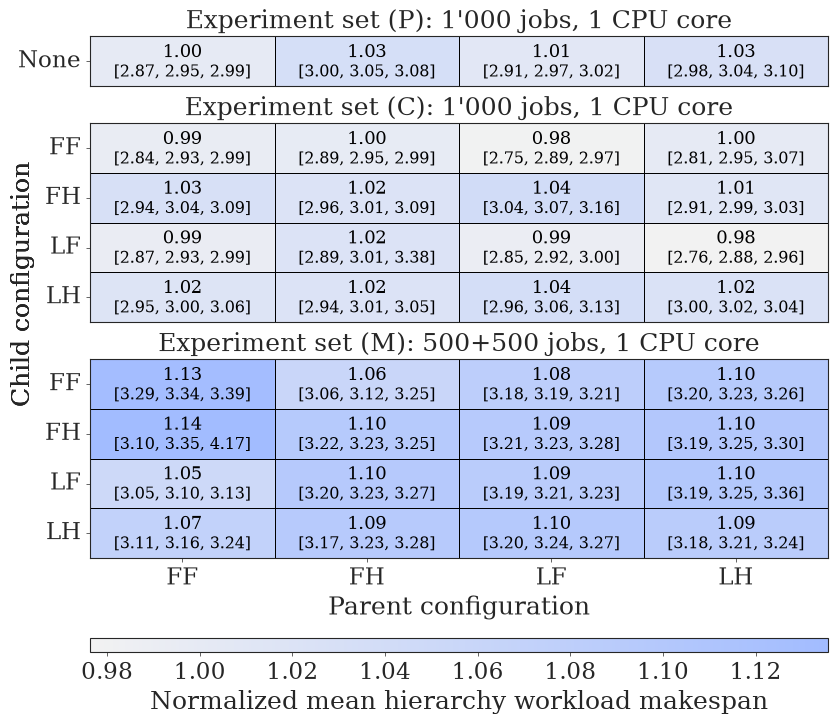

Stream_dane_1000_norm: (P), FF baseline = 220.990280 s


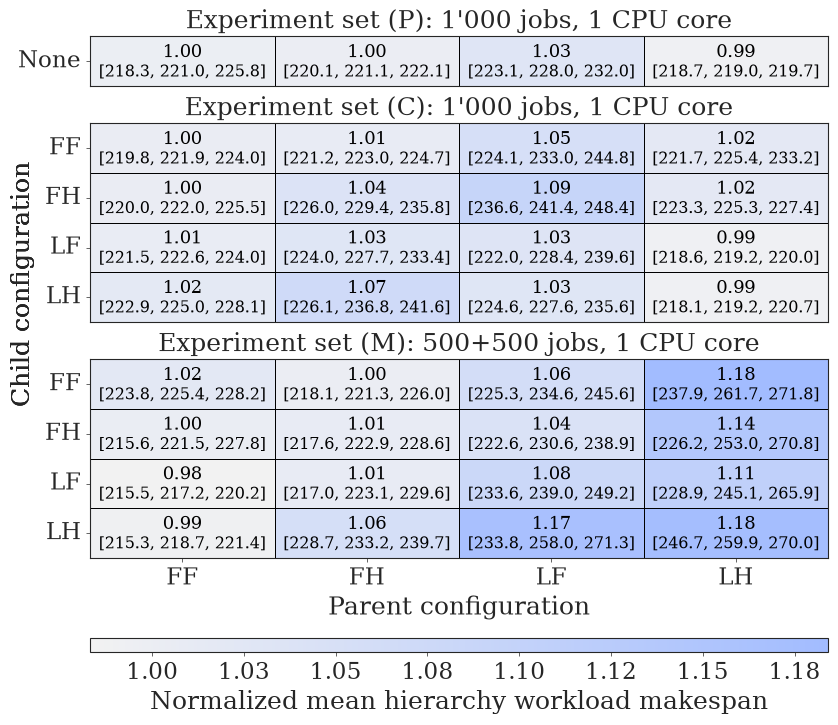

GEMM_tuolumne_40_norm: (P), FF baseline = 155.048317 s


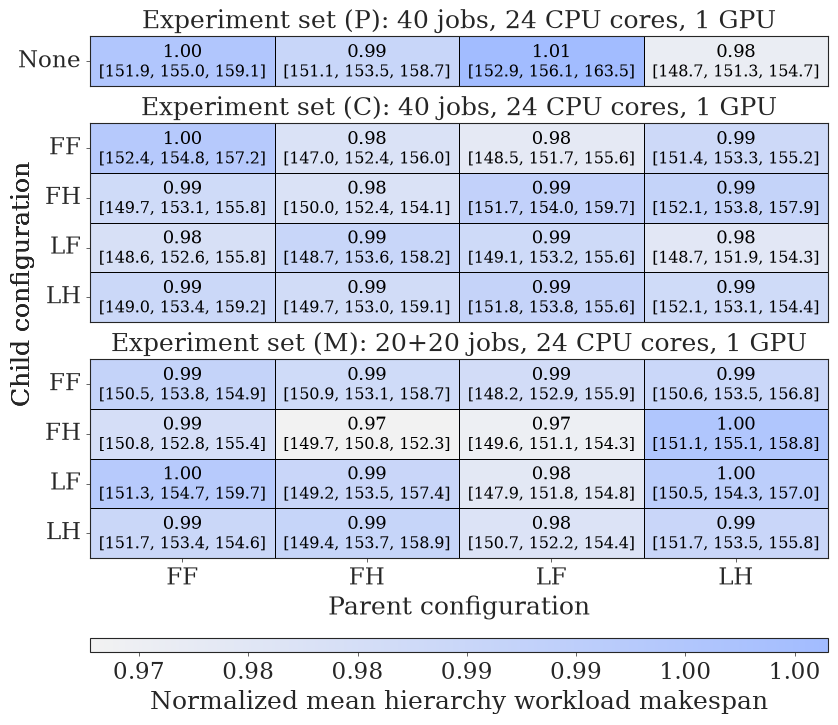

In [6]:
path_svg = Path(plot_path) / 'svg'

metric = 'hierarchy_makespan'
metric_label = 'Normalized mean hierarchy workload makespan'

# One entry creates one figure with P/C/M panels
plot_sets = {
    'Zero_dane_1000_norm': {
        'system': 'dane',
        'workload': 'sleep',
        'problem_class': 'A',
        'job_request_nodes': 1,
        'job_request_ntasks_per_node': 1,
        'job_request_cores_per_task': 1,
        'job_request_gpus_per_task': 0,

        'plots': {
            'P': {
                'title': "Experiment set (P): 1'000 jobs, 1 CPU core",
                'exp_type': 'SO_P',
                'levels': {
                    1: 1000,
                },
            },
            'C': {
                'title': "Experiment set (C): 1'000 jobs, 1 CPU core",
                'exp_type': 'SO_C',
                'levels': {
                    2: 1000,
                },
            },
            'M': {
                'title': "Experiment set (M): 500+500 jobs, 1 CPU core",
                'exp_type': 'SO_M',
                'levels': {
                    1: 500,
                    2: 500,
                },
            },
        },
    },
    'Stream_dane_1000_norm': {
        'system': 'dane',
        'workload': 'babelstream',
        'problem_class': 'B',
        'job_request_nodes': 1,
        'job_request_ntasks_per_node': 1,
        'job_request_cores_per_task': 1,
        'job_request_gpus_per_task': 0,

        'plots': {
            'P': {
                'title': "Experiment set (P): 1'000 jobs, 1 CPU core",
                'exp_type': 'SW_P',
                'levels': {
                    1: 1000,
                },
            },
            'C': {
                'title': "Experiment set (C): 1'000 jobs, 1 CPU core",
                'exp_type': 'SW_C',
                'levels': {
                    2: 1000,
                },
            },
            'M': {
                'title': "Experiment set (M): 500+500 jobs, 1 CPU core",
                'exp_type': 'SW_M',
                'levels': {
                    1: 500,
                    2: 500,
                },
            },
        },
    },
    'GEMM_tuolumne_40_norm': {
        'system': 'tuolumne',
        'workload': 'raja-perf%Polybench_GEMM%Base_HIP',
        'problem_class': 'B',
        'job_request_nodes': 1,
        'job_request_ntasks_per_node': 1,
        'job_request_cores_per_task': 24,
        'job_request_gpus_per_task': 1,

        'plots': {
            'P': {
                'title': "Experiment set (P): 40 jobs, 24 CPU cores, 1 GPU",
                'exp_type': 'SW_P',
                'levels': {
                    1: 40,
                },
            },
            'C': {
                'title': "Experiment set (C): 40 jobs, 24 CPU cores, 1 GPU",
                'exp_type': 'SW_C',
                'levels': {
                    2: 40,
                },
            },
            'M': {
                'title': "Experiment set (M): 20+20 jobs, 24 CPU cores, 1 GPU",
                'exp_type': 'SW_M',
                'levels': {
                    1: 20,
                    2: 20,
                },
            },
        },
    },
}

# Final plot order and labels for the policies
policy_labels = {
    'first-fcfs': 'FF',
    'first-hybrid': 'FH',
    'low-fcfs': 'LF',
    'low-hybrid': 'LH',
}

policy_order = list(policy_labels.keys())

for figure_name, figure_cfg in plot_sets.items():

    heatmaps = {}

    # Prepare P/C/M heatmap data
    for submission, v in figure_cfg['plots'].items():

        # Base selection
        plot_df = data_df[
            (data_df['system'] == figure_cfg['system']) &
            (data_df['exp_type'] == v['exp_type'])
        ].copy()

        # Build filters for the levels receiving workload jobs
        filter_cols = []

        for level, n_jobs in v['levels'].items():

            prefix = f'L{level}_'

            filter_cols.extend([
                (
                    prefix + 'n_jobs',
                    [n_jobs],
                ),
                (
                    prefix + 'workload',
                    [figure_cfg['workload']],
                ),
                (
                    prefix + 'problem_class',
                    [figure_cfg['problem_class']],
                ),
                (
                    prefix + 'job_request_nodes',
                    [figure_cfg['job_request_nodes']],
                ),
                (
                    prefix + 'job_request_ntasks_per_node',
                    [figure_cfg['job_request_ntasks_per_node']],
                ),
                (
                    prefix + 'job_request_cores_per_task',
                    [figure_cfg['job_request_cores_per_task']],
                ),
                (
                    prefix + 'job_request_gpus_per_task',
                    [figure_cfg['job_request_gpus_per_task']],
                ),
            ])

        # Experiment-specific selection
        plot_df = apply_filters(
            plot_df,
            filter_cols,
        )

        # Parent scheduler configuration
        plot_df['L1_policy'] = (
            plot_df['L1_match'] + '-' + plot_df['L1_queue']
        )

        if submission == 'P':

            # Parent only: parent configuration on x-axis
            grouped = (
                plot_df
                .groupby('L1_policy')[metric]
            )

            heatmap_mean = (
                grouped
                .mean()
                .reindex(policy_order)
                .to_frame()
                .T
            )

            heatmap_min = (
                grouped
                .min()
                .reindex(policy_order)
                .to_frame()
                .T
            )

            heatmap_max = (
                grouped
                .max()
                .reindex(policy_order)
                .to_frame()
                .T
            )

        else:

            # Child scheduler configuration
            plot_df['L2_policy'] = (
                plot_df['L2_match'] + '-' + plot_df['L2_queue']
            )

            # Parent on x-axis, child on y-axis
            grouped = (
                plot_df
                .groupby(['L2_policy', 'L1_policy'])[metric]
            )

            heatmap_mean = (
                grouped
                .mean()
                .unstack()
                .reindex(
                    index=policy_order,
                    columns=policy_order,
                )
            )

            heatmap_min = (
                grouped
                .min()
                .unstack()
                .reindex(
                    index=policy_order,
                    columns=policy_order,
                )
            )

            heatmap_max = (
                grouped
                .max()
                .unstack()
                .reindex(
                    index=policy_order,
                    columns=policy_order,
                )
            )

        heatmaps[submission] = {
            'mean': heatmap_mean,
            'min': heatmap_min,
            'max': heatmap_max,
        }

    # Normalize mean values to First-FCFS in experiment set (P)
    baseline = heatmaps['P']['mean'].iloc[0]['first-fcfs']

    print(
        f'{figure_name}: '
        f'(P), FF baseline = {baseline:.6f} s'
    )

    for submission in heatmaps:
        heatmaps[submission]['normalized_mean'] = (
            heatmaps[submission]['mean'] / baseline
        )

    # Shared color scale across P/C/M
    vmin = min(
        values['normalized_mean'].min().min()
        for values in heatmaps.values()
    )

    vmax = max(
        values['normalized_mean'].max().max()
        for values in heatmaps.values()
    )

    # Figure
    fig = plt.figure(
        figsize=(fig_width, fig_height * 2)
    )

    # P/C/M, spacer, horizontal colorbar
    gs = fig.add_gridspec(
        nrows=5,
        ncols=1,
        height_ratios=[1, 4, 4, 0.1, 0.3],
        hspace=0.4,
    )

    fig.subplots_adjust(
        left=0.08,
    )

    axes = [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[1, 0]),
        fig.add_subplot(gs[2, 0]),
    ]

    cbar_ax = fig.add_subplot(gs[4, 0])

    # Plot P/C/M
    for ax, (submission, v) in zip(
        axes,
        figure_cfg['plots'].items(),
    ):

        heatmap_mean = heatmaps[submission]['mean']
        heatmap_min = heatmaps[submission]['min']
        heatmap_max = heatmaps[submission]['max']
        heatmap_normalized = heatmaps[submission]['normalized_mean']

        # Heatmap
        hm = sns.heatmap(
            heatmap_normalized,
            annot=False,
            cmap=heatmap_cmap,
            vmin=vmin,
            vmax=vmax,
            linewidths=0.5,
            linecolor='black',
            cbar=False,
            ax=ax,
        )

        # Normalized mean and absolute [min, mean, max]
        for i in range(heatmap_mean.shape[0]):
            for j in range(heatmap_mean.shape[1]):

                mean = heatmap_mean.iloc[i, j]
                minimum = heatmap_min.iloc[i, j]
                maximum = heatmap_max.iloc[i, j]
                normalized = heatmap_normalized.iloc[i, j]

                if pd.isna(mean):
                    continue

                ax.text(
                    j + 0.5,
                    i + 0.32,
                    f'{normalized:.2f}',
                    ha='center',
                    va='center',
                    fontsize=font_size,
                    color='black',
                )

                ax.text(
                    j + 0.5,
                    i + 0.72,
                    (
                        f'[{format_heatmap_value(minimum)}, '
                        f'{format_heatmap_value(mean)}, '
                        f'{format_heatmap_value(maximum)}]'
                    ),
                    ha='center',
                    va='center',
                    fontsize=font_size * 0.9,
                    color='black',
                )

        # Child configuration labels
        if submission == 'P':
            ax.set_yticklabels(
                ['None'],
                rotation=0,
            )
        else:
            ax.set_yticklabels(
                policy_labels.values(),
                rotation=0,
            )

        ax.set_ylabel('')

        # Shared y-axis label for all P/C/M panels
        fig.text(
            0.005,
            0.57,
            'Child configuration',
            rotation=90,
            va='center',
            ha='center',
            fontproperties=axes[-1].xaxis.label.get_fontproperties(),
        )

        ax.set_title(
            v['title'],
        )

        format_heatmap(
            ax,
            hm,
        )

        # Parent configuration only on bottom panel
        if submission == 'M':

            ax.set_xticklabels(
                policy_labels.values(),
                rotation=0,
            )

            ax.set_xlabel(
                'Parent configuration'
            )

        else:

            ax.set_xticklabels([])
            ax.set_xlabel('')

            ax.tick_params(
                axis='x',
                length=0,
            )

    # Shared horizontal colorbar
    cbar = format_heatmap_colorbar(
        fig,
        axes[-1].collections[0],
        cbar_ax,
        metric_label,
        digits=2
    )

    # Save
    plt.savefig(
        os.path.join(
            path_svg,
            out_folder,
            figure_name + '.svg'
        ),
        format='svg',
        bbox_inches='tight',
        pad_inches=0,
    )

    plt.show()

In [39]:
# Experiment wise check
cores = 24; system = 'tuolumne'; workload = 'raja-perf%Polybench_GEMM%Base_HIP'
L1_match = 'first'; L1_queue = 'fcfs'; L2_match = 'first'; L2_queue = 'fcfs'

exp_type = 'SW_P'; jobs = 40

metrics = ['hierarchy_makespan']

cond = (
    (data_df['system'] == system) &
    (data_df['exp_type'] == exp_type)
)

if exp_type in ['SW_P', 'SW_M']:
    cond &= (
        (data_df['L1_match'] == L1_match) &
        (data_df['L1_queue'] == L1_queue) &
        (data_df['L1_job_request_cores_per_task'] == cores) &
        (data_df['L1_n_jobs'] == jobs) &
        (data_df['L1_workload'] == workload)
    )
if exp_type in ['SW_C', 'SW_M']:
    cond &= (
        (data_df['L2_match'] == L2_match) &
        (data_df['L2_queue'] == L2_queue) &
        (data_df['L2_job_request_cores_per_task'] == cores) &
        (data_df['L2_n_jobs'] == jobs) &
        (data_df['L2_workload'] == workload)
    )

df_check = data_df.loc[cond]

print(df_check[['rep'] + metrics].to_string(index=False))
print(df_check.iloc[0]['hash'])

 rep  hierarchy_makespan
   1          153.900487
   2          153.722915
   4          153.454951
   5          167.225375
2668bac384


In [ ]:
# check some of the results:

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
cores = 1; jobs = 1000; system = 'dane'; workload='sleep'; 
L1_match = 'low'; L1_queue = 'hybrid'; L2_match = 'low'; L2_queue = 'fcfs'

#parent
exp_type = 'SO_P';
metrics = [
    'hierarchy_makespan',
    'L1_jobs_first_submit_to_first_start',
    'L1_jobs_first_start_to_last_submit',
    'L1_jobs_last_submit_to_last_finish',
]
df_check = data_df.loc[
    (data_df['L1_match'] == L1_match) & (data_df['L1_queue'] == L1_queue) 
    & (data_df['L1_job_request_cores_per_task'] == cores) & (data_df['L1_n_jobs'] == jobs) & data_df['L1_workload'].isin([workload])
    & (data_df['system'] == system) & (data_df['exp_type'] == exp_type)
]
print(df_check[['rep'] + metrics].to_string(index=False)); print(df_check.iloc[0]['hash'])

# child
exp_type = 'SO_C';
metrics = [
    'hierarchy_makespan',    
    'L2_jobs_first_submit_to_first_start',
    'L2_jobs_first_start_to_last_submit',
    'L2_jobs_last_submit_to_last_finish',
]
df_check = data_df.loc[
    (data_df['L1_match'] == L1_match) & (data_df['L1_queue'] == L1_queue) 
    & (data_df['L2_match'] == L2_match) & (data_df['L2_queue'] == L2_queue) 
    & (data_df['L2_job_request_cores_per_task'] == cores) & (data_df['L2_n_jobs'] == jobs) & data_df['L2_workload'].isin([workload])
    & (data_df['system'] == system) & (data_df['exp_type'] == exp_type)
]
print(df_check[['rep'] + metrics].to_string(index=False));  print(df_check.iloc[0]['hash'])

# mutlilevel
# check some of the results:
jobs = jobs/2; exp_type = 'SO_M';
metrics = [
    'hierarchy_makespan',
    'L1_jobs_first_submit_to_first_start',
    'L1_jobs_first_start_to_last_submit',

    'between_level_submission_time',

    'L2_jobs_first_submit_to_first_start',
    'L2_jobs_first_start_to_last_submit',
    'L2_jobs_last_submit_to_last_finish',
]
df_check = data_df.loc[
    (data_df['L1_match'] == L1_match) & (data_df['L1_queue'] == L1_queue) 
    & (data_df['L2_match'] == L2_match) & (data_df['L2_queue'] == L2_queue) 
    & (data_df['L1_job_request_cores_per_task'] == cores) & (data_df['L1_n_jobs'] == jobs) & data_df['L1_workload'].isin([workload])
    & (data_df['L2_job_request_cores_per_task'] == cores) & (data_df['L2_n_jobs'] == jobs) & data_df['L2_workload'].isin([workload])
    & (data_df['system'] == system) & (data_df['exp_type'] == exp_type)
]
print(df_check[['rep'] + metrics].to_string(index=False)); print(df_check.iloc[0]['hash'])

 rep  hierarchy_makespan L1_jobs_first_submit_to_first_start L1_jobs_first_start_to_last_submit L1_jobs_last_submit_to_last_finish
   1            3.051466                            0.226429                           0.760174                           2.064863
   2            3.040514                             0.19183                           0.790647                           2.058037
   3            3.007597                            0.175041                           0.805148                           2.027408
   4            3.016586                            0.193434                           0.781189                           2.041963
   5            2.996720                            0.179852                           0.807594                           2.009274
9a549f5e95
 rep  hierarchy_makespan  L2_jobs_first_submit_to_first_start  L2_jobs_first_start_to_last_submit  L2_jobs_last_submit_to_last_finish
   1            4.959733                             0.233662        

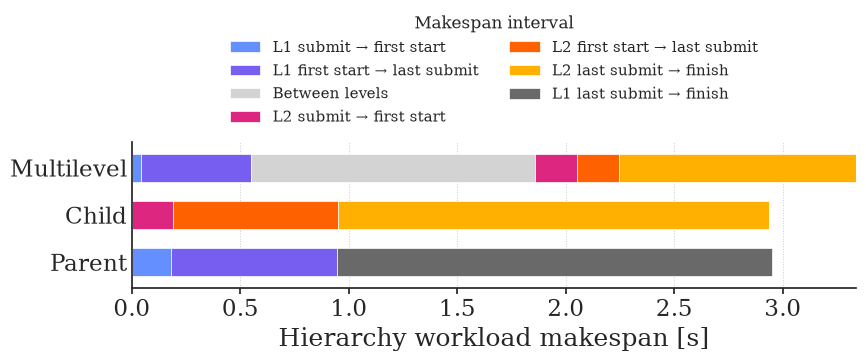

Parent:
  stacked: 2.9506728649139404
  makespan: 2.9506728649139404
Child:
  stacked: 2.9348222732543947
  makespan: 2.9348222732543947
Multilevel:
  stacked: 3.337300729751587
  makespan: 3.337300729751587
Parent:
  stacked: 2.9506728649139404
  makespan: 2.9506728649139404
Child:
  stacked: 2.9348222732543947
  makespan: 2.9348222732543947
Multilevel:
  stacked: 3.337300729751587
  makespan: 3.337300729751587


In [40]:
# Makespan decomposition: P vs. C vs. M

df = data_df.copy()

cores = 1
jobs = 1000
system = 'dane'
workload = 'sleep'

L1_match = 'first'
L1_queue = 'fcfs'
L2_match = 'first'
L2_queue = 'fcfs'


# ============================================================================
# Parent
# ============================================================================

df_p = df.loc[
    (df['system'] == system) &
    (df['exp_type'] == 'SO_P') &
    (df['L1_match'] == L1_match) &
    (df['L1_queue'] == L1_queue) &
    (df['L1_job_request_cores_per_task'] == cores) &
    (df['L1_n_jobs'] == jobs) &
    (df['L1_workload'] == workload)
].copy()

p = {
    'Experiment': 'Parent',
    'Submit → first start':
        df_p['L1_jobs_first_submit_to_first_start'].mean(),
    'First start → last submit':
        df_p['L1_jobs_first_start_to_last_submit'].mean(),
    'Between levels':
        0.0,
    'Last submit → finish':
        df_p['L1_jobs_last_submit_to_last_finish'].mean(),
}


# ============================================================================
# Child
# ============================================================================

df_c = df.loc[
    (df['system'] == system) &
    (df['exp_type'] == 'SO_C') &
    (df['L1_match'] == L1_match) &
    (df['L1_queue'] == L1_queue) &
    (df['L2_match'] == L2_match) &
    (df['L2_queue'] == L2_queue) &
    (df['L2_job_request_cores_per_task'] == cores) &
    (df['L2_n_jobs'] == jobs) &
    (df['L2_workload'] == workload)
].copy()

c = {
    'Experiment': 'Child',
    'Submit → first start':
        df_c['L2_jobs_first_submit_to_first_start'].mean(),
    'First start → last submit':
        df_c['L2_jobs_first_start_to_last_submit'].mean(),
    'Between levels':
        0.0,
    'Last submit → finish':
        df_c['L2_jobs_last_submit_to_last_finish'].mean(),
}


# ============================================================================
# Multilevel
# ============================================================================

df_m = df.loc[
    (df['system'] == system) &
    (df['exp_type'] == 'SO_M') &
    (df['L1_match'] == L1_match) &
    (df['L1_queue'] == L1_queue) &
    (df['L2_match'] == L2_match) &
    (df['L2_queue'] == L2_queue) &
    (df['L1_job_request_cores_per_task'] == cores) &
    (df['L1_n_jobs'] == jobs / 2) &
    (df['L1_workload'] == workload) &
    (df['L2_job_request_cores_per_task'] == cores) &
    (df['L2_n_jobs'] == jobs / 2) &
    (df['L2_workload'] == workload)
].copy()

m = {
    'Experiment': 'Multilevel',

    'L1 submit → first start':
        df_m['L1_jobs_first_submit_to_first_start'].mean(),

    'L1 first start → last submit':
        df_m['L1_jobs_first_start_to_last_submit'].mean(),

    'Between levels':
        df_m['between_level_submission_time'].mean(),

    'L2 submit → first start':
        df_m['L2_jobs_first_submit_to_first_start'].mean(),

    'L2 first start → last submit':
        df_m['L2_jobs_first_start_to_last_submit'].mean(),

    'L2 last submit → finish':
        df_m['L2_jobs_last_submit_to_last_finish'].mean(),
}


# ============================================================================
# Plot data
# ============================================================================

plot_df = pd.DataFrame([
    {
        'Experiment': 'Parent',
        'L1 submit → first start': p['Submit → first start'],
        'L1 first start → last submit': p['First start → last submit'],
        'Between levels': 0.0,
        'L2 submit → first start': 0.0,
        'L2 first start → last submit': 0.0,
        'L2 last submit → finish': 0.0,
        'L1 last submit → finish': p['Last submit → finish'],
    },
    {
        'Experiment': 'Child',
        'L1 submit → first start': 0.0,
        'L1 first start → last submit': 0.0,
        'Between levels': 0.0,
        'L2 submit → first start': c['Submit → first start'],
        'L2 first start → last submit': c['First start → last submit'],
        'L2 last submit → finish': c['Last submit → finish'],
        'L1 last submit → finish': 0.0,
    },
    {
        'Experiment': 'Multilevel',
        'L1 submit → first start': m['L1 submit → first start'],
        'L1 first start → last submit': m['L1 first start → last submit'],
        'Between levels': m['Between levels'],
        'L2 submit → first start': m['L2 submit → first start'],
        'L2 first start → last submit': m['L2 first start → last submit'],
        'L2 last submit → finish': m['L2 last submit → finish'],
        'L1 last submit → finish': 0.0,
    },
]).set_index('Experiment')


# ============================================================================
# Colors
# ============================================================================

phase_colors = {
    # L1
    'L1 submit → first start': ibm_colors_hex[0],
    'L1 first start → last submit': ibm_colors_hex[1],

    # Between L1 and L2
    'Between levels': grey_shades[0],

    # L2
    'L2 submit → first start': ibm_colors_hex[2],
    'L2 first start → last submit': ibm_colors_hex[3],

    # Post-submission processing
    'L2 last submit → finish': ibm_colors_hex[4],
    'L1 last submit → finish': grey_shades[2],
}

plot_colors = [
    phase_colors[col]
    for col in plot_df.columns
]


# ============================================================================
# Plot
# ============================================================================

fig, ax = plt.subplots(
    figsize=(fig_width, fig_height)
)

plot_df.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    width=0.6,
    color=plot_colors,
    edgecolor='white',
    linewidth=0.5,
)

ax.set_xlabel('Hierarchy workload makespan [s]')
ax.set_ylabel('')

ax.tick_params(
    axis='y',
    length=0,
)

ax.grid(
    axis='x',
    linestyle=':',
    linewidth=0.7,
)

ax.set_axisbelow(True)

# Legend
ax.legend(
    title='Makespan interval',
    bbox_to_anchor=(0.5, 1.02),
    loc='lower center',
    ncol=2,
    frameon=False,
    fontsize=font_size - 2,
    title_fontsize=font_size - 1,
)

sns.despine(
    ax=ax,
    top=True,
    right=True,
)

plt.tight_layout()

# Save
path_svg = Path(plot_path) / 'svg'
path_svg.mkdir(parents=True, exist_ok=True)

plt.savefig(
    path_svg / 'hierarchy_makespan_decomposition.svg',
    bbox_inches='tight',
)

plt.show()


# ============================================================================
# Sanity check
# ============================================================================

print('Parent:')
print('  stacked:', plot_df.loc['Parent'].sum())
print('  makespan:', df_p['hierarchy_makespan'].mean())

print('Child:')
print('  stacked:', plot_df.loc['Child'].sum())
print('  makespan:', df_c['hierarchy_makespan'].mean())

print('Multilevel:')
print('  stacked:', plot_df.loc['Multilevel'].sum())
print('  makespan:', df_m['hierarchy_makespan'].mean())

# ============================================================================
# Sanity check: stacked durations vs. measured hierarchy makespan
# ============================================================================

print('Parent:')
print('  stacked:', plot_df.loc['Parent'].sum())
print('  makespan:', df_p['hierarchy_makespan'].mean())

print('Child:')
print('  stacked:', plot_df.loc['Child'].sum())
print('  makespan:', df_c['hierarchy_makespan'].mean())

print('Multilevel:')
print('  stacked:', plot_df.loc['Multilevel'].sum())
print('  makespan:', df_m['hierarchy_makespan'].mean())

## Barplots
<a id='bar-plots'></a>

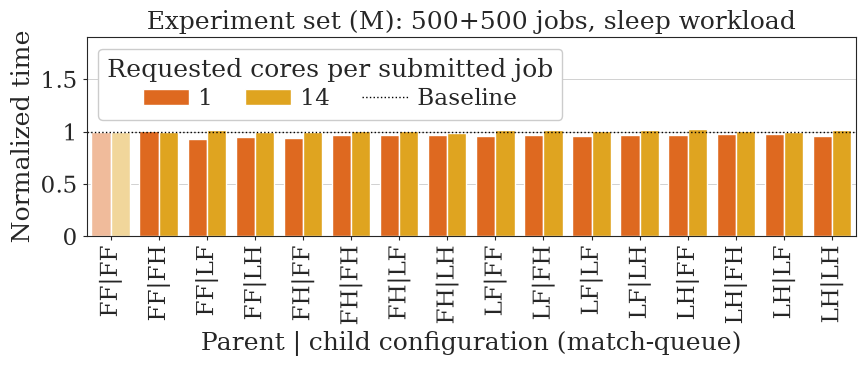

In [43]:
# Multilevel scheduling: comparison of 1 vs. 14 cores/job

df = data_df.copy()

path_svg = Path(plot_path) / 'svg'
metric = 'hierarchy_makespan'
core_col = 'L1_job_request_cores_per_task'

# Only the multilevel sleep experiments of interest
filter_cols = [
    ('system', ['dane']),
    ('exp_type', ['SO_M']),
    ('L1_n_jobs', [500]),
    ('L2_n_jobs', [500]),
    ('L1_workload', ['sleep']),
    ('L2_workload', ['sleep']),
    ('L1_problem_class', ['A']),
    ('L2_problem_class', ['A']),
    ('L1_job_request_cores_per_task', [1, 14]),
    ('L2_job_request_cores_per_task', [1, 14]),
]

df = apply_filters(df, filter_cols)

# We only compare experiments where both hierarchy levels use
# the same resource request.
df = df[
    df['L1_job_request_cores_per_task']
    == df['L2_job_request_cores_per_task']
].copy()


# Scheduling configuration

# Adjust these labels if you already have a helper for the heatmap labels.
df['parent_config'] = (
    df['L1_queue'].astype(str)
    + '/'
    + df['L1_match'].astype(str)
)

df['child_config'] = (
    df['L2_queue'].astype(str)
    + '/'
    + df['L2_match'].astype(str)
)

df['sched_config'] = df['parent_config'] + ' / ' + df['child_config']

# Normalize independently for 1-core and 14-core experiments
# Mean makespan across repetitions for each configuration and core count
df = (
    df.groupby(
        [
            'L1_match', 'L1_queue',
            'L2_match', 'L2_queue',
            core_col,
        ],
        as_index=False
    )
    .agg(**{metric: (metric, 'mean')})
)

# Mean FF|FF value separately for each core count
baseline_mask = (
    (df['L1_queue'] == 'fcfs')
    & (df['L1_match'] == 'first')
    & (df['L2_queue'] == 'fcfs')
    & (df['L2_match'] == 'first')
)

baseline = (
    df[baseline_mask]
    .set_index(core_col)[metric]
)

df['normalized_time'] = (
    df[metric] / df[core_col].map(baseline)
)

# coding for x-axis
match_code = {
    'first': 'F',
    'low': 'L',
    'high': 'H',
    'locality': 'Lc',
}

queue_code = {
    'fcfs': 'F',
    'easy': 'E',
    'conservative': 'C',
    'hybrid': 'H',
}

df['sched_config'] = (
    df['L1_match'].map(match_code)
    + df['L1_queue'].map(queue_code)
    + '|'
    + df['L2_match'].map(match_code)
    + df['L2_queue'].map(queue_code)
)

config_order = [
    ('first', 'fcfs'),
    ('first', 'hybrid'),
    ('low', 'fcfs'),
    ('low', 'hybrid'),
]

def config_label(match, queue):
    return f'{match_code[match]}{queue_code[queue]}'

sched_order = [
    f'{config_label(pm, pq)}|{config_label(cm, cq)}'
    for pm, pq in config_order
    for cm, cq in config_order
]

# Plot
plt.figure(figsize=(fig_width, fig_height))
ax = sns.barplot(
    data=df,
    x='sched_config',
    order=sched_order,
    y='normalized_time',
    hue=core_col,
    hue_order=[1, 14],
    estimator=np.mean,
    errorbar=lambda x: (x.min(), x.max()),
    palette=custom_palette[3:5],
    capsize=0.1,
    err_kws={'color': 'black', 'linewidth': 1},
)

# Highlight the FF|FF baseline bars
def lighten_color(color, amount=0.5):
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(rgb + (1 - rgb) * amount)

# First bar of each hue is FF|FF
for container in ax.containers:
    bar = container[0]
    bar.set_facecolor(lighten_color(bar.get_facecolor(), 0.55))

plt.ylim(0,1.9)
plt.xticks(rotation=90, ha='center')

plt.axhline(
    y=1,
    color='black',
    linestyle=':',
    linewidth=1,
    label='Baseline'
)

plt.xlabel('Parent | child configuration (match-queue)')
plt.ylabel('Normalized time')
# ax.yaxis.set_label_coords(-0.08, 0.42)

plt.legend(
    title='Requested cores per submitted job',
    loc='upper left',
    ncol=3,
    labelspacing=0.2,
    columnspacing=1.4,
    handletextpad=0.4,
    framealpha=1.0,
)

make_grid(ax, plt)

plt.title('Experiment set (M): 500+500 jobs, sleep workload')

formatter(ax)

finisher('SO_M_cores_comparison', plt)

Plot showing the variation for (M) for all 16 configuration combinatison

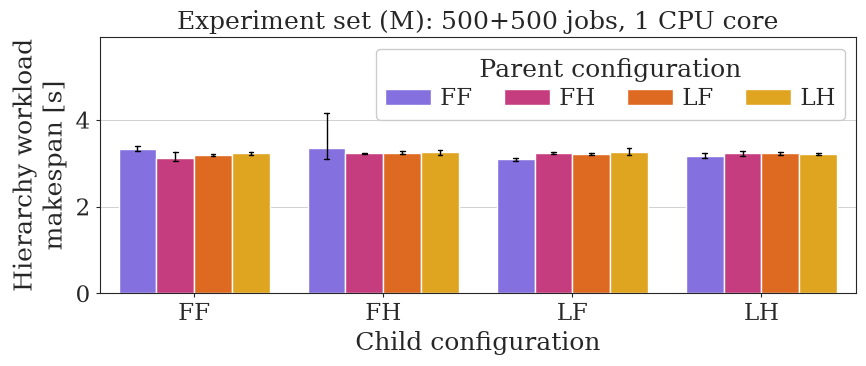

In [46]:
# Multilevel scheduling: parent and child configuration comparison

df = data_df.copy()

path_svg = Path(plot_path) / 'svg'

# Experiment configuration
system = 'dane'
exp_type = 'SO_M'

workload = 'sleep'
workload_label = 'Zero workload'
problem_class = 'A'

n_jobs_parent = 500
n_jobs_child = 500

cores_per_task = 1
gpus_per_task = 0

metric = 'hierarchy_makespan'
metric_label = 'Hierarchy workload\nmakespan [s]'

# Select experiment data
filter_cols = [
    ('system', [system]),
    ('exp_type', [exp_type]),
    ('L1_n_jobs', [n_jobs_parent]),
    ('L2_n_jobs', [n_jobs_child]),
    ('L1_workload', [workload]),
    ('L2_workload', [workload]),
    ('L1_problem_class', [problem_class]),
    ('L2_problem_class', [problem_class]),
    ('L1_job_request_cores_per_task', [cores_per_task]),
    ('L2_job_request_cores_per_task', [cores_per_task]),
    ('L1_job_request_gpus_per_task', [gpus_per_task]),
    ('L2_job_request_gpus_per_task', [gpus_per_task]),
]

df = apply_filters(
    df,
    filter_cols,
)

# Configuration coding
match_code = {
    'first': 'F',
    'low': 'L',
    'high': 'H',
    'locality': 'Lc',
}

queue_code = {
    'fcfs': 'F',
    'easy': 'E',
    'conservative': 'C',
    'hybrid': 'H',
}

config_order = [
    ('first', 'fcfs'),
    ('first', 'hybrid'),
    ('low', 'fcfs'),
    ('low', 'hybrid'),
]

def config_label(match, queue):
    return f'{match_code[match]}{queue_code[queue]}'

policy_order = [
    config_label(match, queue)
    for match, queue in config_order
]

df['parent_config'] = (
    df['L1_match'].map(match_code)
    + df['L1_queue'].map(queue_code)
)

df['child_config'] = (
    df['L2_match'].map(match_code)
    + df['L2_queue'].map(queue_code)
)

# Plot
plt.figure(
    figsize=(fig_width, fig_height)
)

ax = sns.barplot(
    data=df,
    x='child_config',
    order=policy_order,
    y=metric,
    hue='parent_config',
    hue_order=policy_order,
    estimator=np.mean,
    errorbar=lambda x: (x.min(), x.max()),
    palette=custom_palette[1:5],
    capsize=0.1,
    err_kws={
        'color': 'black',
        'linewidth': 1,
    },
)

ax.set_ylim(0, 5.9)

plt.xlabel(
    'Child configuration'
)

plt.ylabel(
    metric_label
)

plt.legend(
    title='Parent configuration',
    loc='upper right',
    ncol=4,
    labelspacing=0.2,
    columnspacing=1.4,
    handletextpad=0.4,
    framealpha=1.0,
)

make_grid(
    ax,
    plt,
)

plt.title(
    # f'Experiment set (M): '
    # f'{n_jobs_parent}+{n_jobs_child} jobs, '
    # f'{workload_label}'
    'Experiment set (M): 500+500 jobs, 1 CPU core'
)

formatter(
    ax
)

finisher(
    'SO_M_configuration_comparison',
    plt
)